In [1]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
! ls /home/pratyush/Backing_Array_run/ROOT_files/4_March_2026

Thresh230-5min_100ns_grouping2.root  Thresh260-5min_10ns_grouping2.root
Thresh260-5min_100ns_grouping2.root  Thresh290-5min_100ns_grouping2.root


In [18]:
fname = "/home/pratyush/Backing_Array_run/ROOT_files/4_March_2026/Thresh290-5min_100ns_grouping2.root"
tree_name = "Events"
#branches = ["TStamp_us","Board_Id","Num_Hits","CH_Id","DataType","ToA_LSB","ToT_LSB","t_abs_us","Ring","Event_Id"]
branches = ["Board_Id","Num_Hits","CH_Id","Ring","Event_Id"]

dfs = []
for df in uproot.iterate(f"{fname}:{tree_name}", expressions=branches, library="pd", step_size=200_000):
    dfs.append(df)

big_df = pd.concat(dfs, ignore_index=True)
print(big_df.shape)

(30766505, 5)


In [19]:
big_df.head()

,Board_Id,Num_Hits,CH_Id,Ring,Event_Id
0,1,18,4,17,1
1,1,18,63,6,1
2,1,18,14,3,1
3,1,18,15,3,1
4,1,18,10,3,1


In [11]:
!ls -l 28_April_2026/SourceOnRing14

total 447560
-rw-rw-r-- 1 pratyush pratyush 458296398 Apr 29 14:13 Counts_50000_5min_10ns_csv_grouping2.parquet


In [2]:
import uproot
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq


def root_to_parquet_stream(
    fname,
    out_parquet,
    tree_name="Events",
    branches=("Board_Id", "Num_Hits", "CH_Id", "Ring", "Event_Id"),
    step_size=200_000,
    compression="zstd",
    return_rows_only=True,
):
    """
    Stream a ROOT TTree into a Parquet file chunk-by-chunk.

    Parameters
    ----------
    fname : str
        Path to the input ROOT file.
    out_parquet : str
        Path to the output parquet file.
    tree_name : str
        TTree name inside the ROOT file.
    branches : tuple/list
        Branches to read.
    step_size : int
        Chunk size for uproot.iterate.
    compression : str
        Parquet compression codec, e.g. 'zstd', 'snappy', 'gzip'.
    return_rows_only : bool
        If True, return only total row count.
        If False, also return the final schema.

    Returns
    -------
    int or (int, pyarrow.Schema)
        Total number of rows written, and optionally schema.
    """

    dtype_map = {
        "Board_Id": "uint8",
        "Num_Hits": "uint16",
        "CH_Id": "uint16",
        "Ring": "uint16",
        "Event_Id": "uint32",
    }

    writer = None
    total_rows = 0
    schema = None

    try:
        for i, df in enumerate(
            uproot.iterate(
                f"{fname}:{tree_name}",
                expressions=list(branches),
                library="pd",
                step_size=step_size,
            )
        ):
            # Cast only columns present in this chunk
            cast_map = {col: dtype_map[col] for col in df.columns if col in dtype_map}
            df = df.astype(cast_map, copy=False)

            table = pa.Table.from_pandas(df, preserve_index=False)

            if writer is None:
                schema = table.schema
                writer = pq.ParquetWriter(
                    out_parquet,
                    schema=schema,
                    compression=compression,
                )

            writer.write_table(table)
            total_rows += len(df)

            print(f"Chunk {i:>4}: wrote {len(df):>10} rows | total = {total_rows}")

    finally:
        if writer is not None:
            writer.close()

    print(f"Done. Wrote {total_rows} rows to: {out_parquet}")

    if return_rows_only:
        return total_rows
    return total_rows, schema

In [3]:
! ls 28_April_2026

Background_Data  SourceOnRing10  SourceOnRing14  SourceOnRing2	SourceOnRing6


In [4]:
fname = "/home/pratyush/Backing_Array_run/ROOT_files/28_April_2026/Background_Data/Counts_50000_5min_10ns_csv_grouping2.root"
out_parquet = "28_April_2026/Background_Data/Counts_50000_5min_10ns_csv_grouping2.parquet"

nrows = root_to_parquet_stream(
    fname=fname,
    out_parquet=out_parquet,
    tree_name="Events",
    branches=("Board_Id", "Num_Hits", "CH_Id", "Ring","ToT_LSB","Event_Id"),
    step_size=200_000,
    compression="zstd",
)

print("Total rows written:", nrows)

Chunk    0: wrote     200000 rows | total = 200000
Chunk    1: wrote     200000 rows | total = 400000
Chunk    2: wrote     200000 rows | total = 600000
Chunk    3: wrote     200000 rows | total = 800000
Chunk    4: wrote     200000 rows | total = 1000000
Chunk    5: wrote     200000 rows | total = 1200000
Chunk    6: wrote     200000 rows | total = 1400000
Chunk    7: wrote     200000 rows | total = 1600000
Chunk    8: wrote     200000 rows | total = 1800000
Chunk    9: wrote     200000 rows | total = 2000000
Chunk   10: wrote     200000 rows | total = 2200000
Chunk   11: wrote     200000 rows | total = 2400000
Chunk   12: wrote     200000 rows | total = 2600000
Chunk   13: wrote     200000 rows | total = 2800000
Chunk   14: wrote     200000 rows | total = 3000000
Chunk   15: wrote     200000 rows | total = 3200000
Chunk   16: wrote     200000 rows | total = 3400000
Chunk   17: wrote     200000 rows | total = 3600000
Chunk   18: wrote     200000 rows | total = 3800000
Chunk   19: wrot

In [3]:
!ls  4_march_2026

4_March_2026_Thresh230-5min_100ns_grouping2.parquet
4_March_2026_Thresh260-5min_100ns_grouping2.parquet
4_March_2026_Thresh290-5min_100ns_grouping2.parquet


In [18]:
big_df = pd.read_parquet("18_Feb_2026/18_Feb_2026_Thresh230-5min_100ns_grouping2.parquet")
big_df.head()

,Board_Id,Num_Hits,CH_Id,Ring,ToT_LSB,Event_Id
0,3,108,24,12,30,1
1,0,30,34,15,63,2
2,3,108,25,12,19,2
3,3,108,17,26,34,2
4,2,43,10,7,17,2


In [4]:
big_df = pd.read_parquet("4_march_2026/4_March_2026_Thresh260-5min_100ns_grouping2.parquet")
big_df.head()

,Board_Id,Num_Hits,CH_Id,Ring,ToT_LSB,Event_Id
0,2,12,30,8,6,1
1,1,59,14,3,25,1
2,1,59,20,18,29,1
3,3,42,2,25,25,1
4,1,59,22,18,6,1


In [5]:
!ls 28_April_2026/Background_Data/Counts_50000_5min_10ns_csv_grouping2.parquet

Counts_50000_5min_10ns_csv_grouping2.parquet


In [2]:
big_df = pd.read_parquet("28_April_2026/Background_Data/Counts_50000_5min_10ns_csv_grouping2.parquet")
big_df.head()

,Board_Id,Num_Hits,CH_Id,Ring,ToT_LSB,Event_Id
0,0,201,32,15,-1,1
1,0,201,33,15,-1,1
2,0,201,57,2,-1,1
3,1,254,62,6,-1,1
4,0,201,49,16,-1,1


In [3]:
big_df_2 = pd.read_parquet("4_march_2026/4_March_2026_Thresh260-5min_100ns_grouping2.parquet")
big_df_2.head()

,Board_Id,Num_Hits,CH_Id,Ring,ToT_LSB,Event_Id
0,2,12,30,8,6,1
1,1,59,14,3,25,1
2,1,59,20,18,29,1
3,3,42,2,25,25,1
4,1,59,22,18,6,1


In [6]:
big_df_3 = pd.read_parquet("4_march_2026/4_March_2026_Thresh290-5min_100ns_grouping2.parquet")
big_df_3.head()

,Board_Id,Num_Hits,CH_Id,Ring,Event_Id
0,1,18,4,17,1
1,1,18,63,6,1
2,1,18,14,3,1
3,1,18,15,3,1
4,1,18,10,3,1


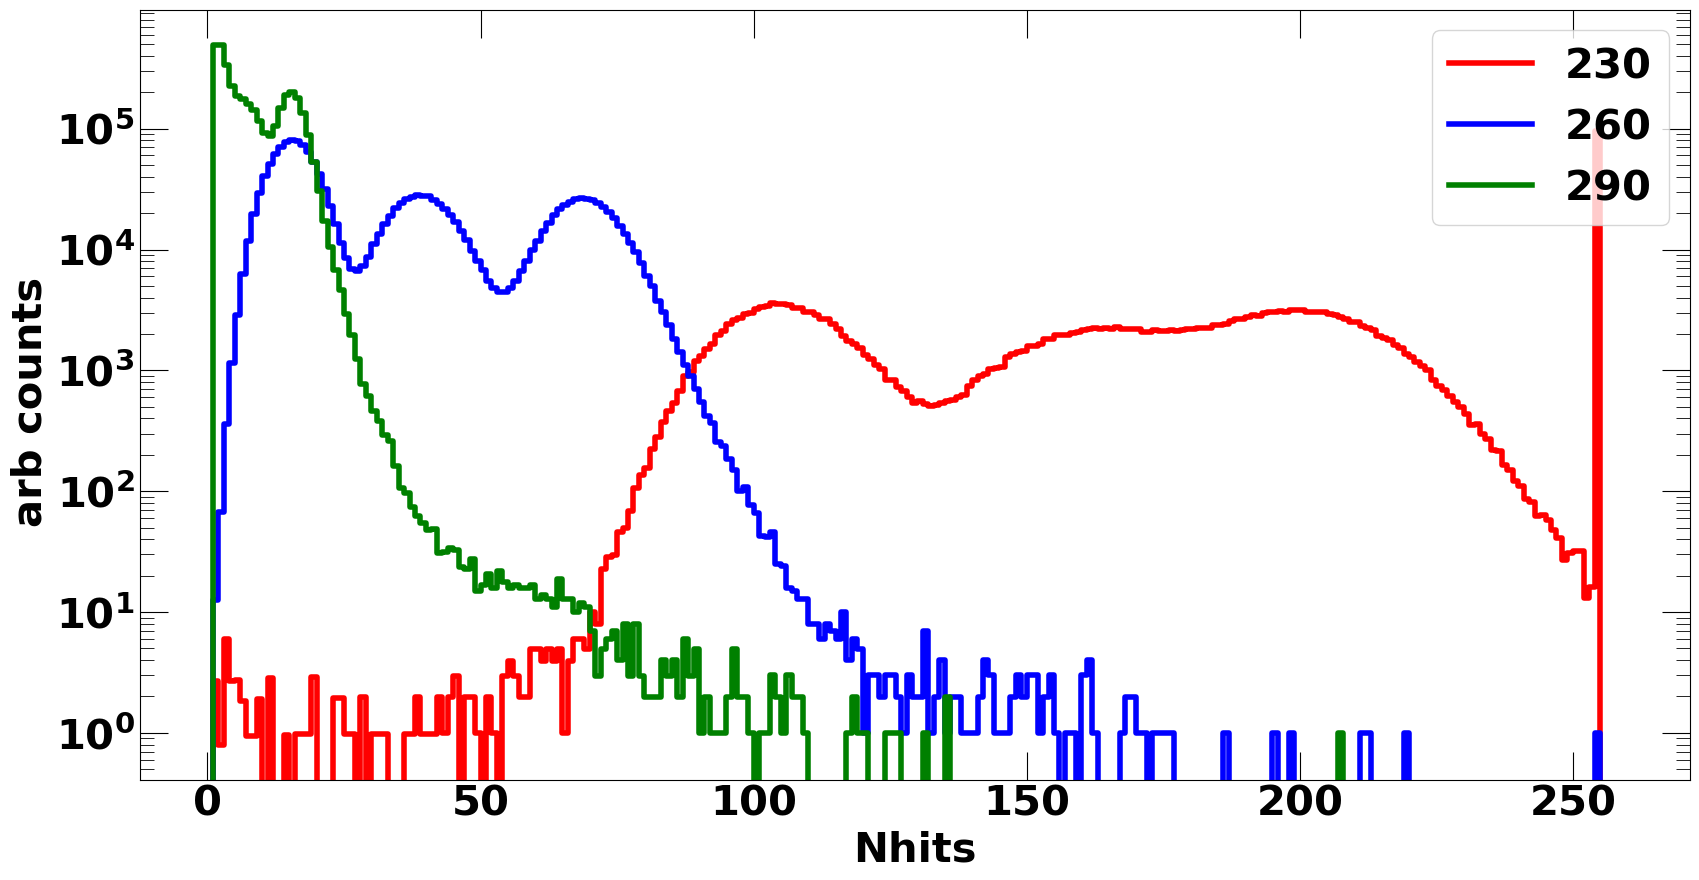

In [26]:

fig = plt.figure(1,figsize=(20,10))

n_CPD,bins=np.histogram(np.asarray(big_df['Num_Hits']), bins=np.arange(0,260,1), density=False)
bin_centers= 0.5*(bins[1:] + bins[:-1])
y = n_CPD / bin_centers
plt.step(bin_centers, y ,where='mid',color='red',linestyle='-',linewidth=4, label = "230")

n_CPD,bins=np.histogram(np.asarray(big_df_2['Num_Hits']), bins=np.arange(0,260,1), density=False)
y = n_CPD / bin_centers
plt.step(bin_centers, y ,where='mid',color='Blue',linestyle='-',linewidth=4, label = "260")


n_CPD,bins=np.histogram(np.asarray(big_df_3['Num_Hits']), bins=np.arange(0,260,1), density=False)
y = n_CPD / bin_centers
plt.step(bin_centers, y ,where='mid',color='green',linestyle='-',linewidth=4, label = "290")

plt.yscale("log")
plt.xlabel(r'Nhits', fontsize=30,fontweight='bold')
plt.ylabel('arb counts ', fontsize=30,fontweight='bold')
plt.tick_params(direction='in',which='minor',length=10,bottom=True, top =True, left=True, right=True)
plt.tick_params(direction='in',which='major',length=20,bottom=True, top =True, left=True, right=True)
plt.xticks(fontsize=30,fontweight='bold')
plt.yticks(fontsize=30,fontweight='bold')

plt.legend(prop={'weight':"bold", 'size':30}, loc='upper right')

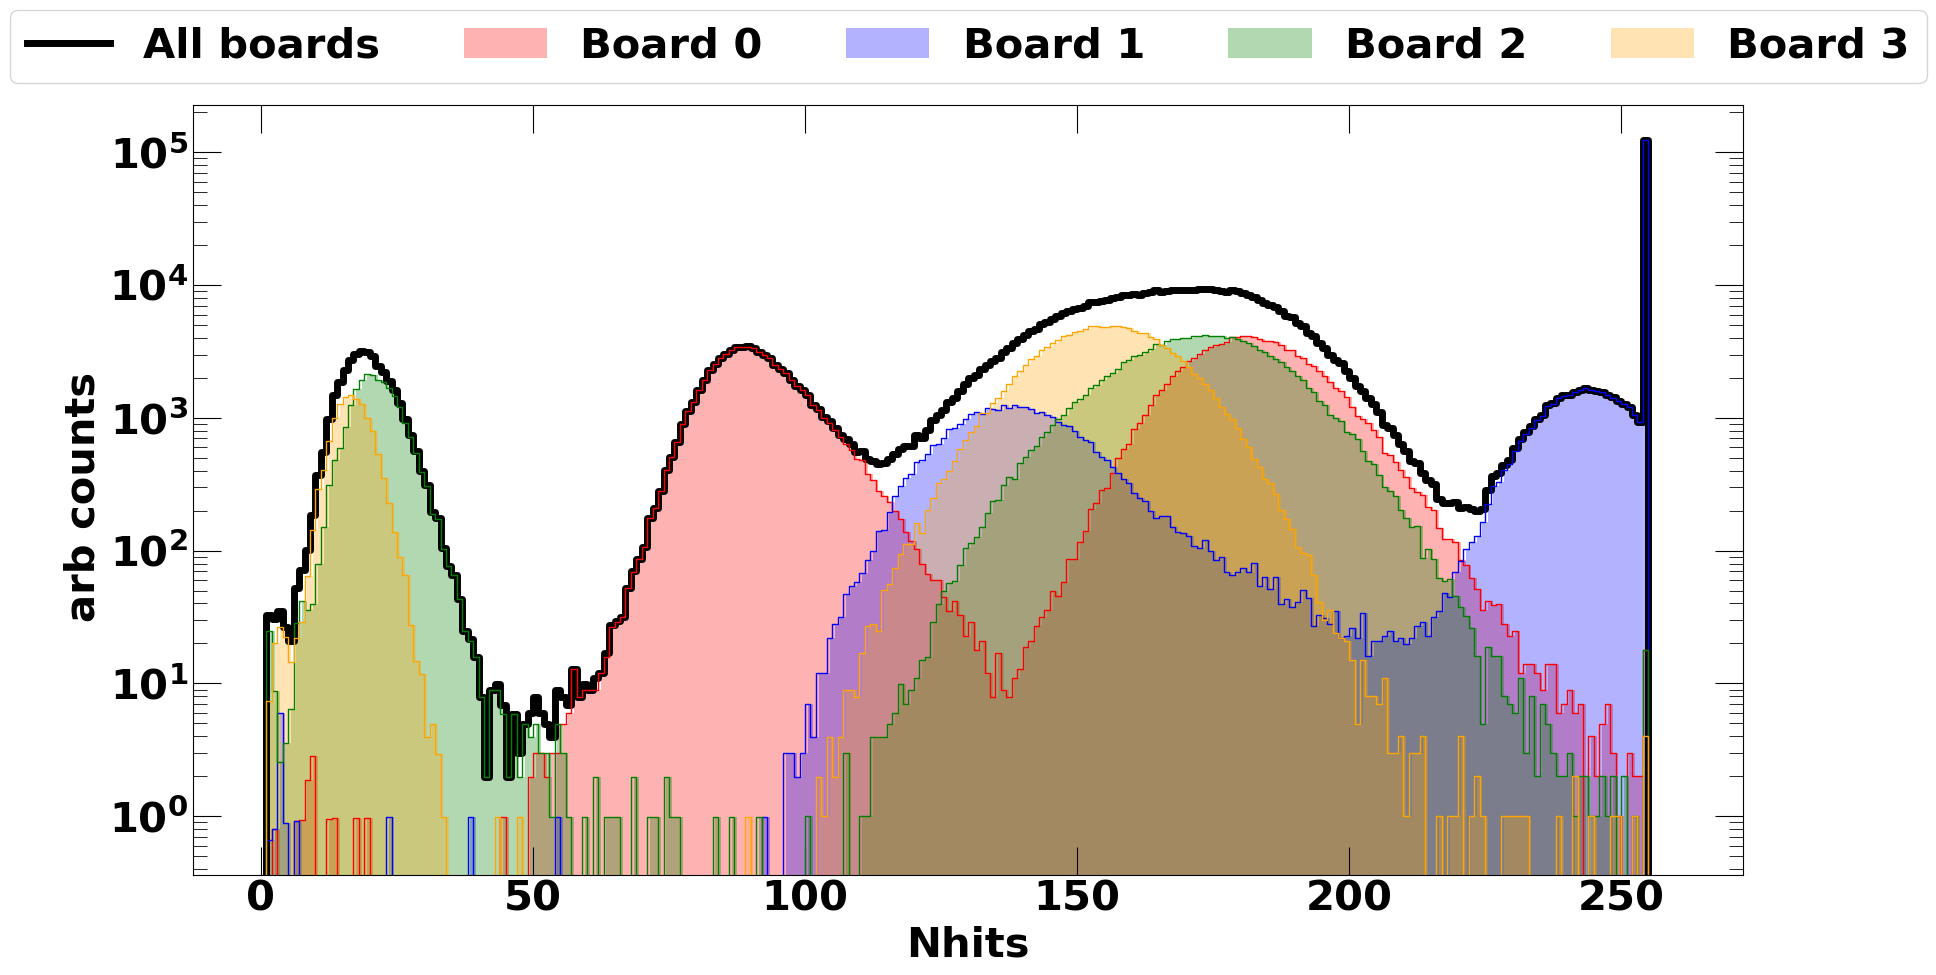

In [6]:
fig = plt.figure(1,figsize=(20,10))

bins = np.arange(0,260,1)

# All hits
all_hits, bins = np.histogram(big_df["Num_Hits"], bins=bins)

bin_centers = 0.5*(bins[1:] + bins[:-1])


y = all_hits / bin_centers

plt.step(bin_centers, y,
         where='mid',
         color='black',
         linewidth=5,
         label="All boards")

colors = {0:"red", 1:"blue", 2:"green", 3:"orange"}

for board in sorted(big_df["Board_Id"].unique()):

    data = big_df.loc[big_df["Board_Id"] == board, "Num_Hits"]

    counts, _ = np.histogram(data, bins=bins)
    y = counts / bin_centers

    plt.step(bin_centers, y,
             where='mid',
             linewidth=1,
             color=colors.get(board,"gray"))
    
    plt.bar(bin_centers, y, width=1, align='edge', color=colors.get(board,"gray"), alpha=0.3, label=f"Board {board}")


plt.yscale("log")
plt.xlabel(r'Nhits', fontsize=30,fontweight='bold')
plt.ylabel('arb counts ', fontsize=30,fontweight='bold')
plt.tick_params(direction='in',which='minor',length=10,bottom=True, top =True, left=True, right=True)
plt.tick_params(direction='in',which='major',length=20,bottom=True, top =True, left=True, right=True)
plt.xticks(fontsize=30,fontweight='bold')
plt.yticks(fontsize=30,fontweight='bold')

plt.legend(prop={'weight':"bold", 'size':30},
           loc='upper center', ncol=5,
           bbox_to_anchor=(0.5, 1.15))

In [ ]:

# Sum Num_Hits for each unique (Event_Id, Board_Id)
event_board_nhits = (
    big_df.groupby(["Event_Id", "Board_Id"], as_index=False)["Num_Hits"]
          .sum()
)

# Histogram of the summed Num_Hits
vals = event_board_nhits["Num_Hits"].to_numpy()

plt.figure(figsize=(8,5))
plt.hist(vals, bins=np.arange(0,260,1), histtype="step", linewidth=2)
plt.xlabel("Summed Num_Hits per unique (Event_Id, Board_Id)")
plt.ylabel("Counts")
plt.yscale("log")   # optional
plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from collections import Counter, defaultdict

# -----------------------------
# 1. Ring map
# -----------------------------
ring_map = {
    0: [
        [47, 45, 43, 41, 46, 44, 42, 40],
        [63, 61, 59, 57, 62, 60, 58, 56],
        [39, 37, 35, 33, 38, 36, 34, 32],
        [55, 53, 51, 49, 54, 52, 50, 48],
    ],
    1: [
        [15, 14, 13, 12, 11, 10, 9, 8],
        [31, 30, 29, 28, 27, 26, 25, 24],
        [47, 46, 45, 44, 43, 42, 41, 40],
        [63, 62, 61, 60, 58, 57, 56],
        [7, 6, 5, 4, 3, 2, 1, 0],
        [23, 22, 21, 20, 19, 18, 17, 16],
        [39, 38, 37, 36, 35, 34, 33, 32],
        [55, 54, 53, 52, 51, 50, 49, 48],
    ],
    2: [
        [15, 14, 13, 12, 11, 10, 9, 8],
        [31, 30, 29, 28, 27, 26, 25, 24],
        [47, 46, 45, 44, 43, 42, 41, 40],
        [63, 62, 61, 60, 59, 58, 57, 56],
        [7, 6, 5, 4, 3, 2, 1, 0],
        [23, 22, 21, 20, 19, 18, 17, 16],
        [39, 38, 37, 36, 35, 34, 33, 32],
        [55, 54, 53, 52, 51, 50, 49, 48],
    ],
    3: [
        [15, 14, 13, 12, 11, 10, 9, 8],
        [31, 30, 29, 28, 27, 26, 25, 24],
        [47, 46, 45, 44, 43, 42, 41, 40],
        [63, 62, 61, 60, 59, 58, 57, 56],
        [7, 6, 5, 4, 3, 2, 1, 0],
        [23, 22, 21, 20, 19, 18, 17, 16],
        [39, 38, 37, 36, 35, 34, 33, 32],
        [55, 54, 53, 52, 51, 50, 49, 48],
    ]
}

ring_counter_assignment = np.array([
    1, 2, 15, 16, 3, 4, 5, 6,
    17, 18, 19, 20, 7, 8, 9, 10,
    21, 22, 23, 24, 11, 12, 13, 14,
    25, 26, 27, 28
])

board_ring_labels = {}
global_ring_idx = 0

for board_id, ring_lists in ring_map.items():
    board_ring_labels[board_id] = []
    for ring_list in ring_lists:
        ring_num = int(ring_counter_assignment[global_ring_idx])
        board_ring_labels[board_id].append(ring_num)
        global_ring_idx += 1

# -----------------------------
# 2. Chunked Parquet reading
# -----------------------------
parquet_file = "28_April_2026/Background_Data/Counts_50000_5min_10ns_csv_grouping2.parquet"   # change this
duration_s = 75.0
file_label = parquet_file
batch_size = 1_000_000

pf = pq.ParquetFile(parquet_file)

# check column name
schema_cols = pf.schema.names
board_col = "Board_Id" if "Board_Id" in schema_cols else "Brd_Id"

needed_cols = [board_col, "CH_Id"]

counts_by_board_ch = Counter()

for batch in pf.iter_batches(batch_size=batch_size, columns=needed_cols):
    chunk = batch.to_pandas()

    grouped = chunk.groupby([board_col, "CH_Id"]).size()

    for key, val in grouped.items():
        counts_by_board_ch[(int(key[0]), int(key[1]))] += int(val)

    del chunk, grouped

print("Finished counting.")
print("Unique board-channel pairs:", len(counts_by_board_ch))

Finished counting.
Unique board-channel pairs: 208


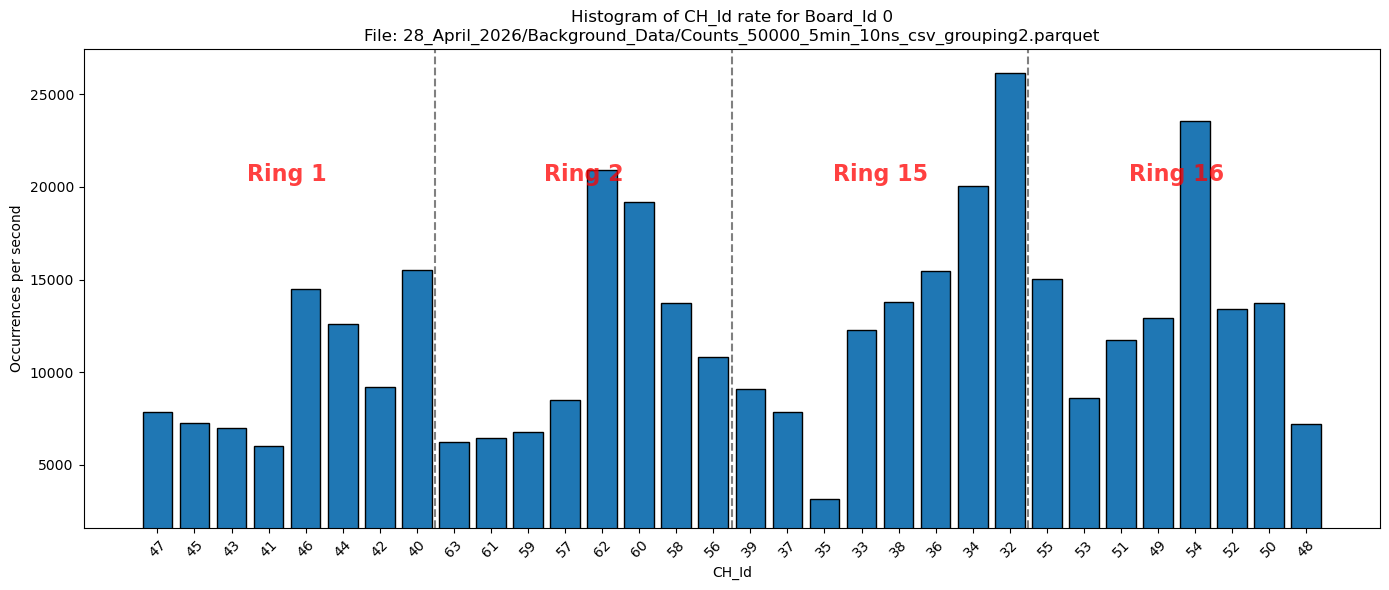

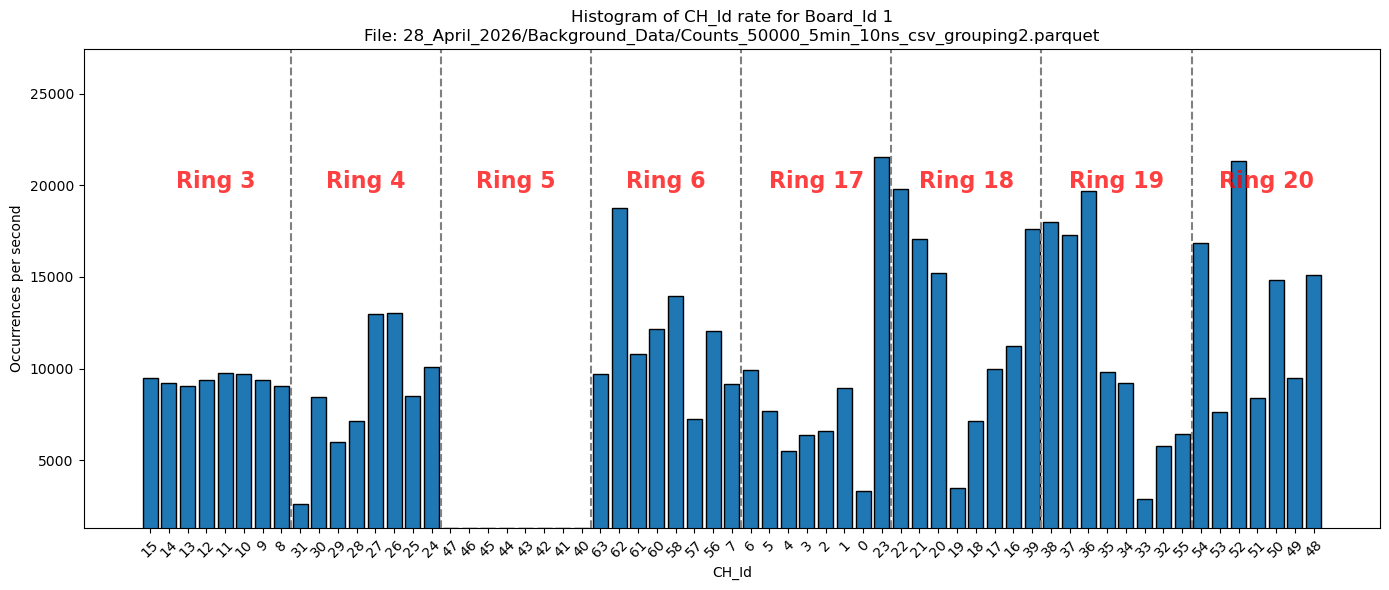

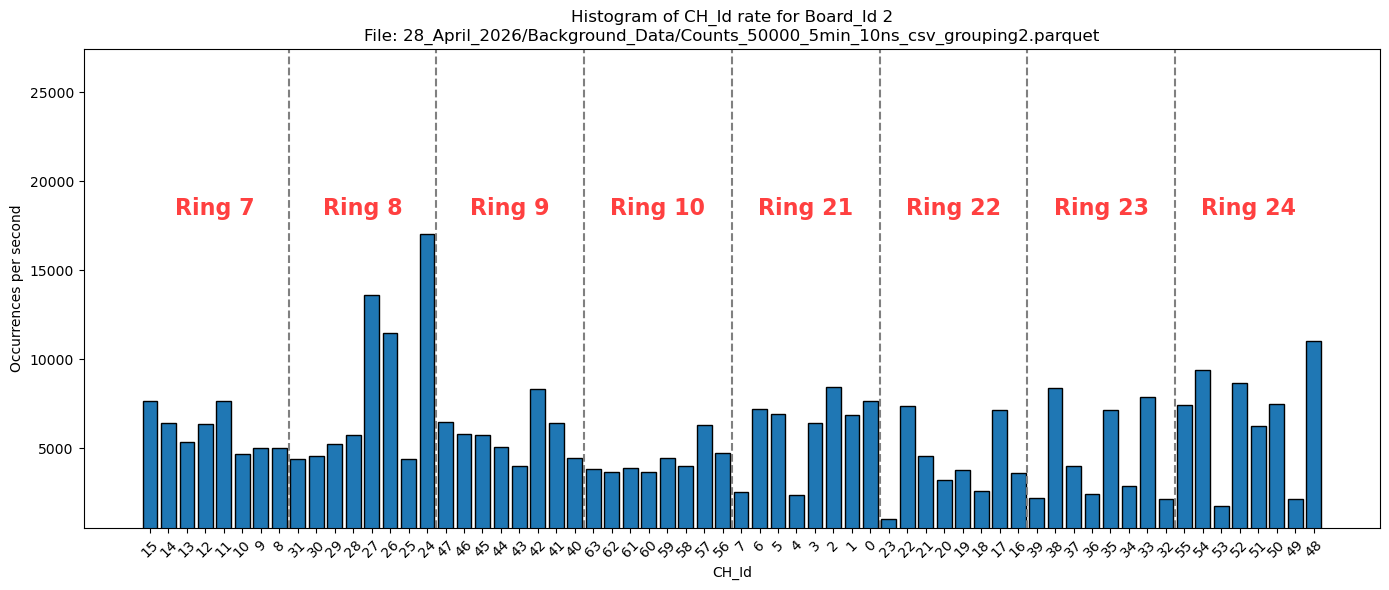

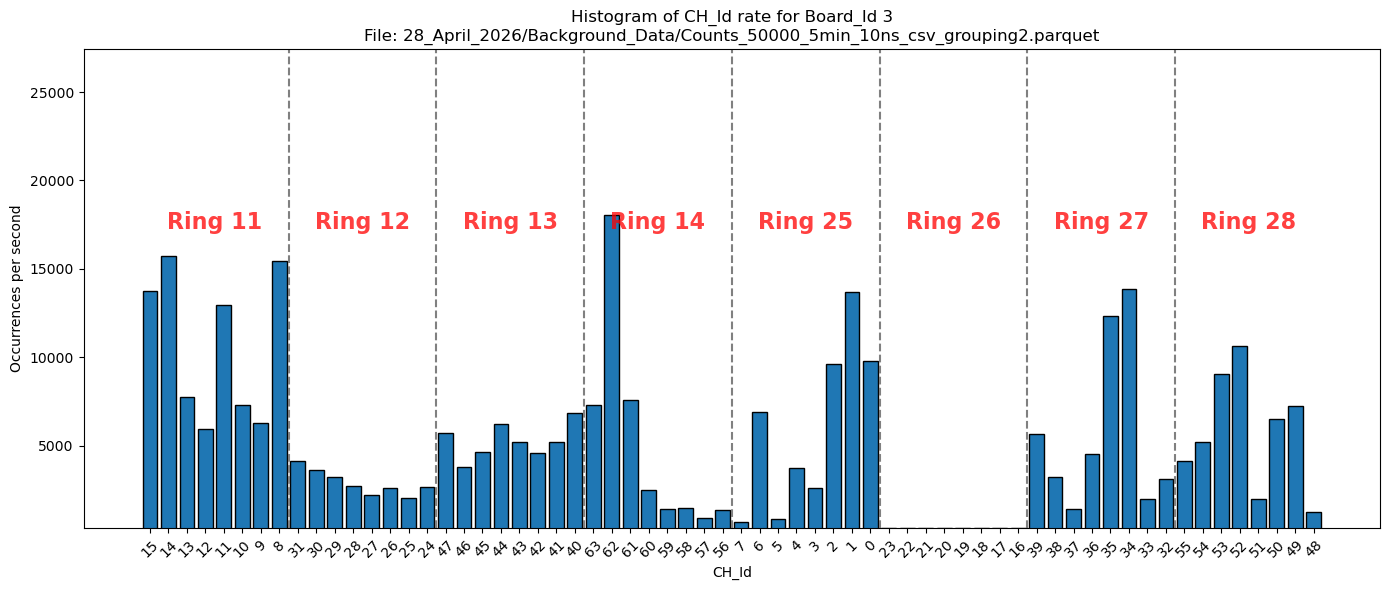

In [5]:
# -----------------------------
# 3. Plot per board
# -----------------------------
board_ids = sorted({b for (b, ch) in counts_by_board_ch.keys()})

global_max_counts = max(counts_by_board_ch.values()) if counts_by_board_ch else 0
global_max_rate = global_max_counts / duration_s if duration_s > 0 else 1.0
y_upper = global_max_rate * 1.05 if global_max_rate > 0 else 1.0

for board_id in board_ids:
    if board_id not in ring_map:
        print(f"Skipping Board_Id {board_id}: not in ring_map")
        continue

    channel_order = [ch for ring in ring_map[board_id] for ch in ring]

    counts = np.array(
        [counts_by_board_ch.get((board_id, ch), 0) for ch in channel_order],
        dtype=float
    )

    rates = counts / duration_s

    positive_rates = rates[rates > 0]
    min_positive = positive_rates.min() if len(positive_rates) > 0 else 1.0
    safe_min = min_positive * 0.5

    rates_for_plot = np.where(rates > 0, rates, safe_min)

    x = np.arange(len(channel_order))

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(x, rates_for_plot, align="center", edgecolor="black")

    ax.set_xlabel("CH_Id")
    ax.set_ylabel("Occurrences per second")
    ax.set_title(
        f"Histogram of CH_Id rate for Board_Id {board_id}\n"
        f"File: {file_label}"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(channel_order, rotation=45)

    y_low = max(safe_min, 1e-2)
    y_high = max(y_upper, y_low * 10)
    ax.set_ylim(y_low, y_high)

    n_rings = len(ring_map[board_id])
    for i in range(1, n_rings):
        ax.axvline(i * 8 - 0.5, color="gray", linestyle="dashed")

    y_label_pos = y_low * (y_high / y_low) ** 0.9

    for i, ring_num in enumerate(board_ring_labels[board_id]):
        center = i * 8 + 3.5
        ax.text(
            center,
            y_label_pos,
            f"Ring {ring_num}",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color="red",
            alpha=0.75,
        )

    plt.tight_layout()
    plt.show()

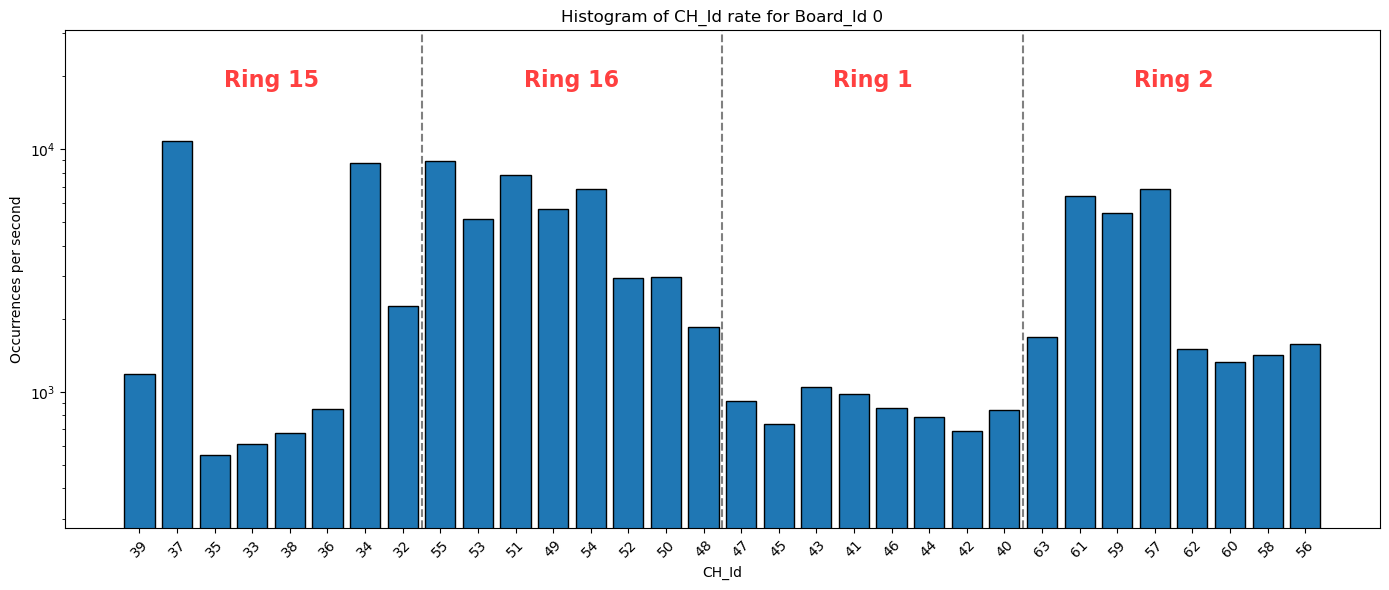

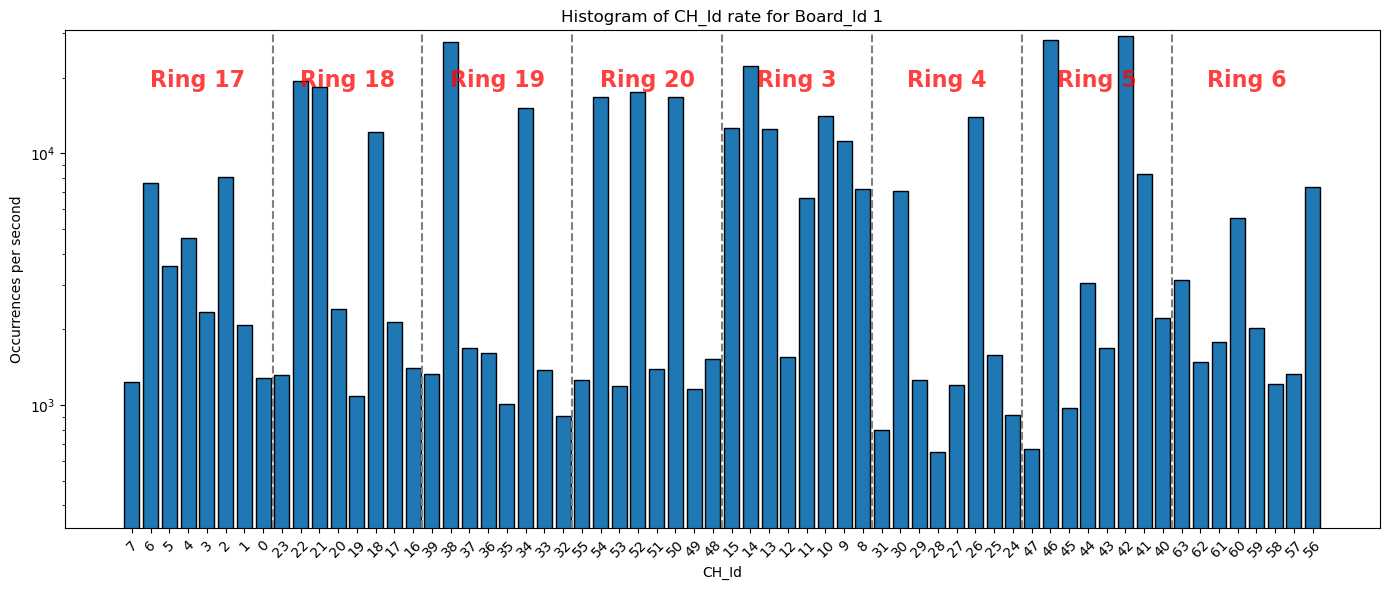

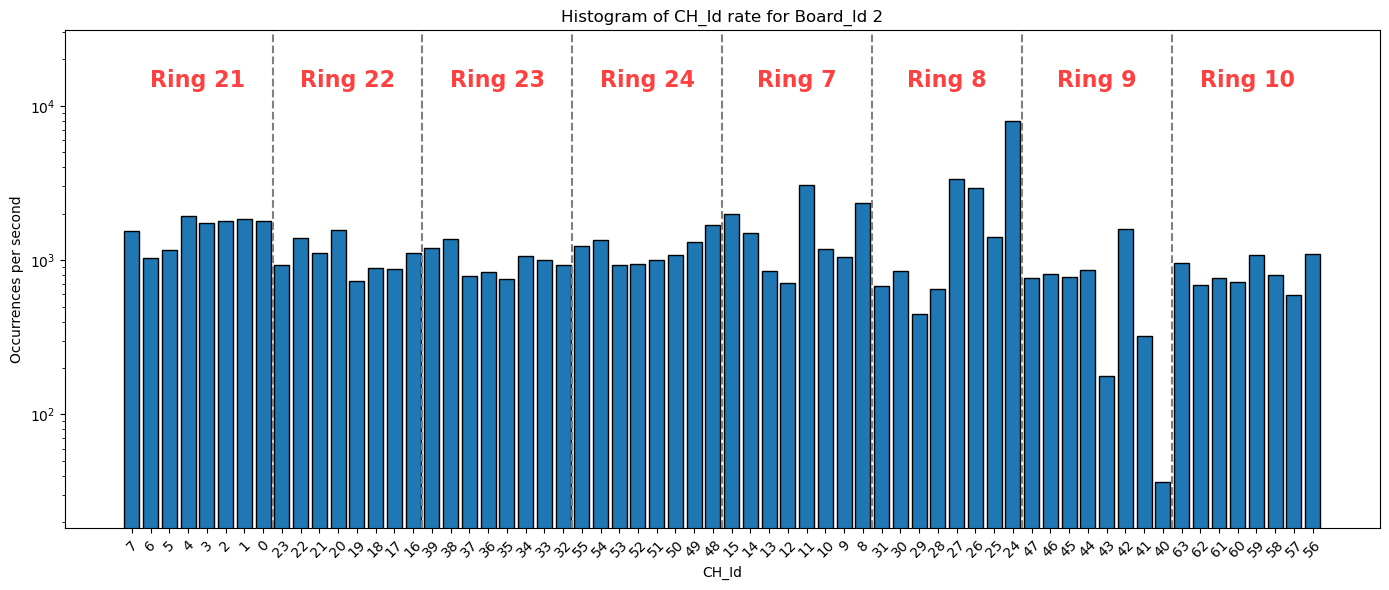

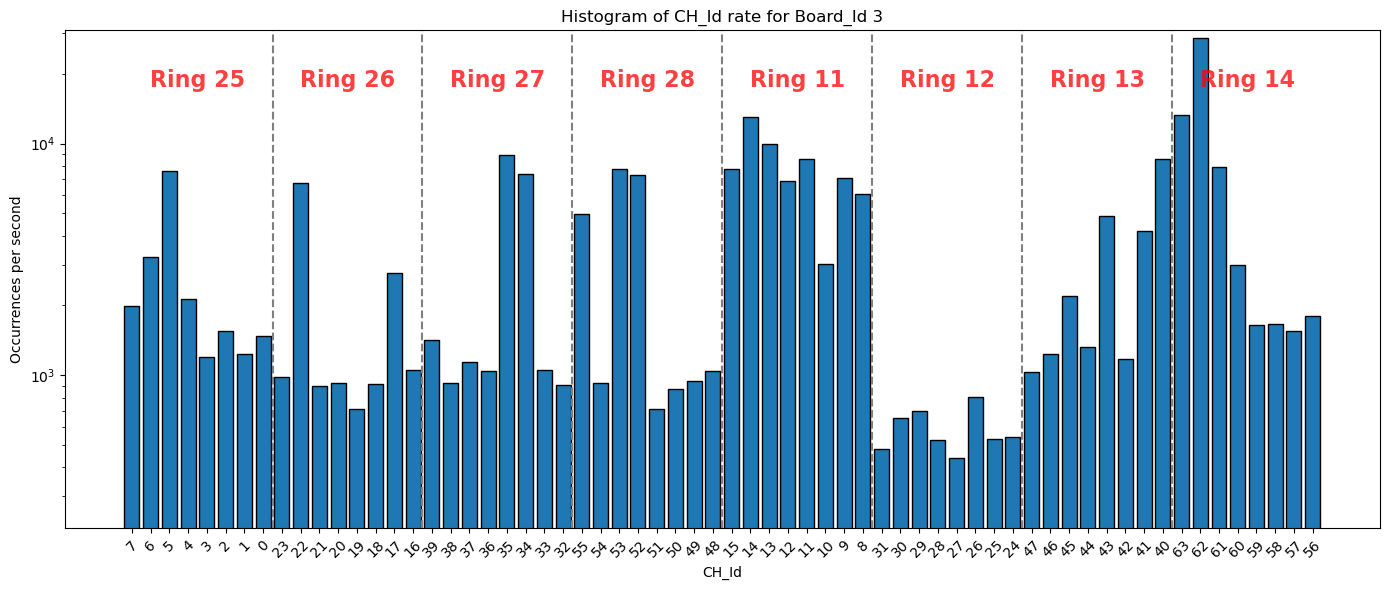

In [26]:
# -----------------------------
# Helper: rotate rings by half
# -----------------------------
def rotate_ring_blocks(ring_lists, ring_labels):
    n = len(ring_lists)
    half = n // 2
    return ring_lists[half:] + ring_lists[:half], ring_labels[half:] + ring_labels[:half]

# -----------------------------
# Plot per board
# -----------------------------
board_ids = sorted(df[board_col].unique())

for board_id in board_ids:
    sub_df = df[df[board_col] == board_id]

    # original ring blocks and labels
    ring_lists = ring_map[board_id]
    ring_labels = board_ring_labels[board_id]

    # swap left/right halves for ALL boards
    ring_lists_rot, ring_labels_rot = rotate_ring_blocks(ring_lists, ring_labels)

    # flattened channel order after swap
    channel_order = [ch for ring in ring_lists_rot for ch in ring]

    counts = (
        sub_df['CH_Id']
        .value_counts()
        .reindex(channel_order, fill_value=0)
    )
    
    #counts = (
    #sub_df.groupby(['Event_Id', 'CH_Id'])
    #      .size()
    #      .reset_index()[ 'CH_Id' ]
    #      .value_counts()
    #      .reindex(channel_order, fill_value=0))

    rates = counts.to_numpy(dtype=float) / duration_s

    positive_rates = rates[rates > 0]
    min_positive = positive_rates.min() if len(positive_rates) > 0 else 1.0
    safe_min = min_positive * 0.5
    rates_for_plot = np.where(rates > 0, rates, safe_min)

    x = np.arange(len(channel_order))

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(x, rates_for_plot, edgecolor='black')

    ax.set_xlabel('CH_Id')
    ax.set_ylabel('Occurrences per second')
    ax.set_title(f'Histogram of CH_Id rate for Board_Id {board_id}')
    ax.set_xticks(x)
    ax.set_xticklabels(channel_order, rotation=45)

    ax.set_yscale('log')
    y_low = max(safe_min, 1e-2)
    y_high = max(y_upper, y_low * 10)
    ax.set_ylim(y_low, y_high)

    # dashed boundaries every ring block
    for i in range(1, len(ring_lists_rot)):
        ax.axvline(i * 8 - 0.5, color='gray', linestyle='dashed')

    # ring labels higher up
    y_label_pos = y_low * (y_high / y_low) ** 0.9
    for i, ring_num in enumerate(ring_labels_rot):
        center = i * 8 + 3.5
        ax.text(
            center, y_label_pos, f"Ring {ring_num}",
            ha='center', va='center',
            fontsize=16, fontweight='bold',
            color='red', alpha=0.75
        )

    plt.tight_layout()
    plt.show()

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. Ring map
# -------------------------------------------------
ring_map = {
    0: [
        [47, 45, 43, 41, 46, 44, 42, 40],
        [63, 61, 59, 57, 62, 60, 58, 56],
        [39, 37, 35, 33, 38, 36, 34, 32],
        [55, 53, 51, 49, 54, 52, 50, 48],
    ],
    1: [
        [15, 14, 13, 12, 11, 10, 9, 8],
        [31, 30, 29, 28, 27, 26, 25, 24],
        [47, 46, 45, 44, 43, 42, 41, 40],
        [63, 62, 61, 60, 59, 58, 57, 56],
        [7, 6, 5, 4, 3, 2, 1, 0],
        [23, 22, 21, 20, 19, 18, 17, 16],
        [39, 38, 37, 36, 35, 34, 33, 32],
        [55, 54, 53, 52, 51, 50, 49, 48],
    ],
    2: [
        [15, 14, 13, 12, 11, 10, 9, 8],
        [31, 30, 29, 28, 27, 26, 25, 24],
        [47, 46, 45, 44, 43, 42, 41, 40],
        [63, 62, 61, 60, 59, 58, 57, 56],
        [7, 6, 5, 4, 3, 2, 1, 0],
        [23, 22, 21, 20, 19, 18, 17, 16],
        [39, 38, 37, 36, 35, 34, 33, 32],
        [55, 54, 53, 52, 51, 50, 49, 48],
    ],
    3: [
        [15, 14, 13, 12, 11, 10, 9, 8],
        [31, 30, 29, 28, 27, 26, 25, 24],
        [47, 46, 45, 44, 43, 42, 41, 40],
        [63, 62, 61, 60, 59, 58, 57, 56],
        [7, 6, 5, 4, 3, 2, 1, 0],
        [23, 22, 21, 20, 19, 18, 17, 16],
        [39, 38, 37, 36, 35, 34, 33, 32],
        [55, 54, 53, 52, 51, 50, 49, 48],
    ]
}

ring_counter_assignment = np.array([
    1, 2, 15, 16, 3, 4, 5, 6,
    17, 18, 19, 20, 7, 8, 9, 10,
    21, 22, 23, 24, 11, 12, 13, 14,
    25, 26, 27, 28
])

# -------------------------------------------------
# 2. Build lookup: ring number -> (board, channel list)
# -------------------------------------------------
ring_to_board_channels = {}
global_ring_idx = 0

for board_id, ring_lists in ring_map.items():
    for ch_list in ring_lists:
        ring_num = int(ring_counter_assignment[global_ring_idx])
        ring_to_board_channels[ring_num] = {
            "board_id": board_id,
            "channels": ch_list
        }
        global_ring_idx += 1

# -------------------------------------------------
# 3. Plot function
# -------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

def plot_tot_by_board_rotated(
    df,
    board_ring_labels,
    ring_to_board_channels,
    tot_col="ToT_LSB",
    board_col="Board_Id",
    ch_col="CH_Id",
    bins=100,
    tot_range=(0, 500),
    alpha=0.9,
    linewidth=1.2
):
    fig, axes = plt.subplots(4, 8, figsize=(34, 16))
    axes = np.asarray(axes)

    channel_colors = [
        "red",
        "green",
        "blue",
        "brown",
        "magenta",
        "orange",
        "black",
        "gold"
    ]

    for board_id in [0, 1, 2, 3]:
        ring_labels = board_ring_labels[board_id]

        # rotate half so left/right are swapped
        half = len(ring_labels) // 2
        ring_labels = ring_labels[half:] + ring_labels[:half]

        for j in range(8):
            ax = axes[board_id, j]

            if j >= len(ring_labels):
                ax.axis("off")
                continue

            ring_num = ring_labels[j]
            info = ring_to_board_channels[ring_num]
            channels = info["channels"]

            sub = df[df[board_col] == board_id]

            found_any = False
            for k, ch in enumerate(channels):
                vals = sub.loc[sub[ch_col] == ch, tot_col].dropna().to_numpy()
                if len(vals) == 0:
                    continue

                found_any = True
                ax.hist(
                    vals,
                    bins=bins,
                    range=tot_range,
                    histtype="step",
                    linewidth=linewidth,
                    alpha=alpha,
                    color=channel_colors[k % len(channel_colors)],
                    label=f"CH {ch}"
                )

            ax.set_title(
                f"Ring {ring_num} | Board {board_id}",
                fontsize=14
            )

            # Fixed axis ranges
            ax.set_xlim(0, 500)
            ax.set_ylim(1, 1e6)
            ax.set_yscale("log")

            # Only selected ticks
            ax.set_xticks([0, 250, 500])
            ax.set_yticks([1, 1e3, 1e6])
            ax.set_yticklabels(["1", "1e3", "1e6"], fontsize=12)
            ax.set_xticklabels(["0", "250", "500"], fontsize=12)

            # Grid
            ax.grid(True, which="major", linestyle="--", alpha=0.6)

            # Axis labels
            if board_id == 3:
                ax.set_xlabel("ToT_LSB", fontsize=14)
            if j == 0:
                ax.set_ylabel("Counts", fontsize=14)

            # Larger tick labels
            ax.tick_params(axis='both', labelsize=12)

            if found_any:
                ax.legend(fontsize=9, ncol=2, frameon=False)
            else:
                ax.text(
                    0.5, 0.5, "No data",
                    transform=ax.transAxes,
                    ha="center", va="center",
                    fontsize=12
                )

    plt.tight_layout()
    plt.show()

In [16]:
board_ring_labels = {
    0: [15,16,1,2],
    1: [17,18,19,20,3,4,5,6],
    2: [21,22,23,24,7,8,9,10],
    3: [25,26,27,28,11,12,13,14]
}

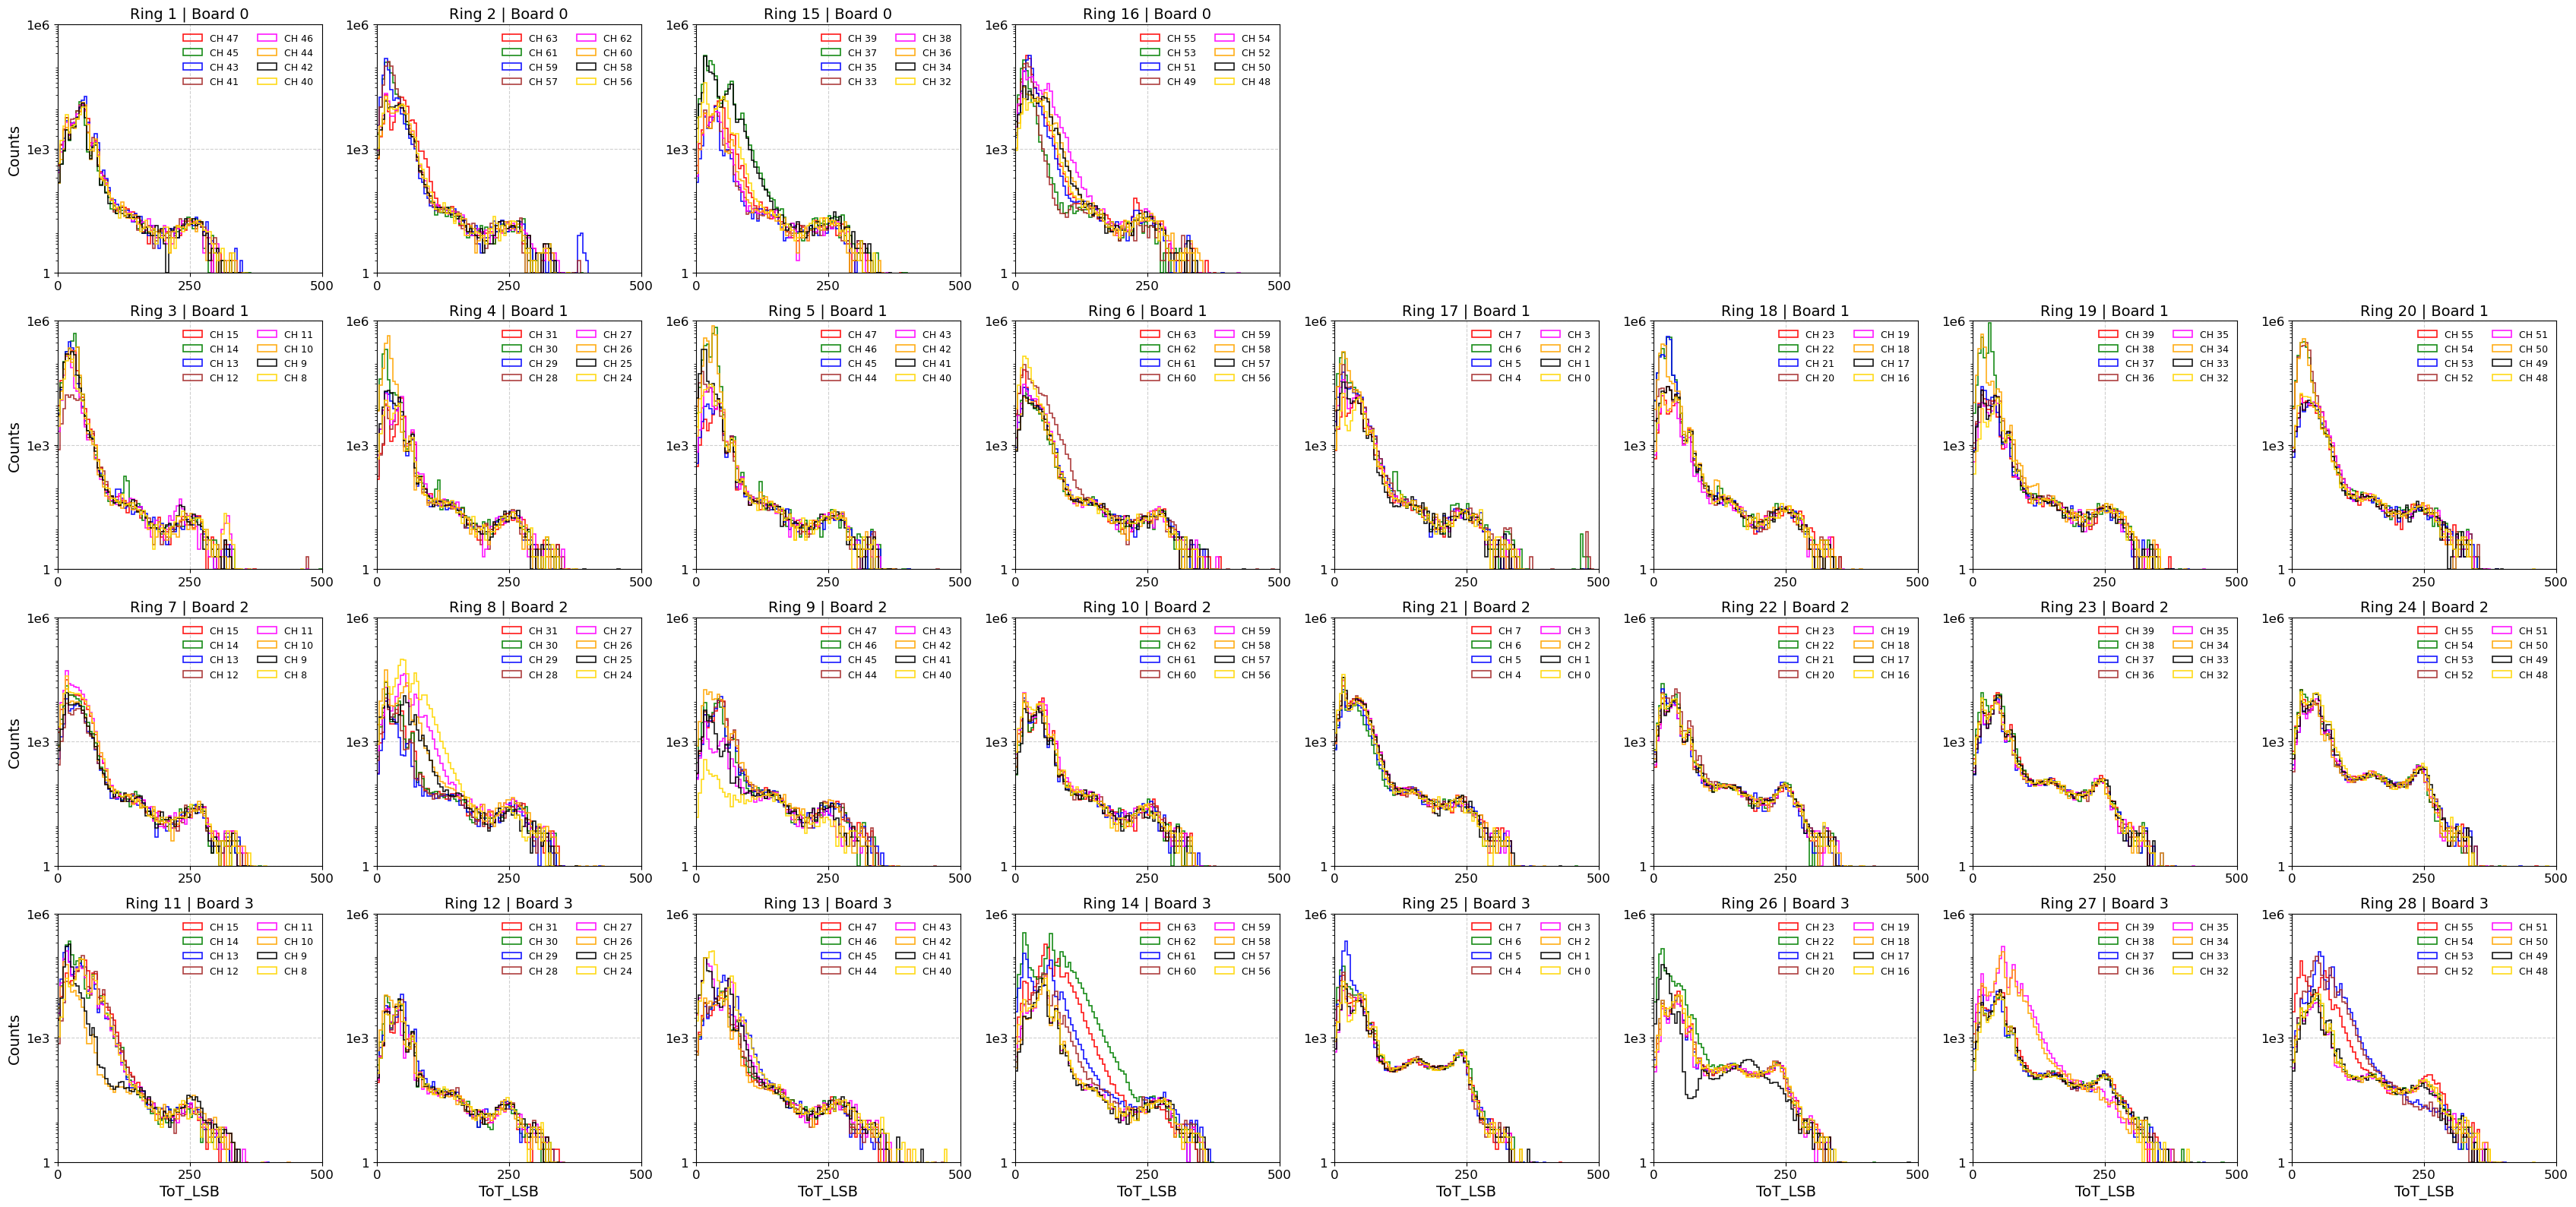

In [17]:
plot_tot_by_board_rotated(
    big_df_2,
    board_ring_labels,
    ring_to_board_channels,
    tot_col="ToT_LSB",
    board_col="Board_Id",
    ch_col="CH_Id",
    bins=100,
    tot_range=(0, 500),
    alpha=0.9,
    linewidth=1.2
)